In [3]:
import pandas as pd

df_fbref = pd.read_csv("/content/fbref_big5_brasileirao_2526_V2.csv")

print("shape: ")
print(df_fbref.shape)
print("head: ")
print(df_fbref.head())

print("------")
df_fbref.isnull().sum()

shape: 
(2953, 123)
head: 
   Rk             Player  Nation    Pos              Squad               Comp  \
0   1   Brenden Aaronson   usUSA  MF,FW       Leeds United  engPremier League   
1   2        Zach Abbott  engENG     DF  Nottingham Forest  engPremier League   
2   4      Himad Abdelli   dzALG     MF          Marseille          frLigue 1   
3   6           Ali Abdi   tnTUN  MF,DF               Nice          frLigue 1   
4   7  Salis Abdul Samed   ghGHA     MF               Nice          frLigue 1   

      Age    Born  MP  Starts  ...  Cartoes_amarelos  Bloqueios_por_90  \
0  25-204  2000.0  35      28  ...               3.0               0.1   
1  20-001  2006.0   3       2  ...               NaN               NaN   
2  26-178  1999.0   8       1  ...               2.0               0.3   
3  32-145  1993.0  21      12  ...               2.0               0.3   
4  26-049  2000.0  18      12  ...               3.0               0.1   

   Penaltis_sofridos  Cartoes_vermelhos  

,0
Rk,0
Player,0
Nation,3
Pos,0
Squad,0
...,...
Jogos_sem_sofrer_gols,2796
Percentual_defesas,2843
Defesas_por_90,2843
Gols_evitados,2843


In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def converter_valor(valor):

    valor = valor.replace("€", "").strip()

    if "mi." in valor.lower():
        numero = float(valor.lower().replace("mi.", "").strip())
        return numero * 1_000_000

    if "mil" in valor.lower():
        numero = float(valor.lower().replace("mil", "").strip())
        return numero * 1_000

    return None

headers = {
    "User-Agent": "Mozilla/5.0"
}

jogadores =  []

for pagina in range(1, 9):
  print(f"Coletando página {pagina}")

  url = f"https://www.transfermarkt.com.br/spieler-statistik/wertvollstespieler/marktwertetop/plus/0?galerie=0&page={pagina}"
  response = requests.get(url, headers=headers)
  soup = BeautifulSoup(response.text, "html.parser")

  for linha in soup.find_all("tr", class_=["odd", "even"]):
    nome = linha.find("td", class_="hauptlink")
    valor = linha.find("td", class_="rechts hauptlink")

    if nome and valor:
      jogador_obj = {
          "nome": nome.get_text(strip=True),
          "valor_mercado": converter_valor(valor.get_text(strip=True))
      }

      jogadores.append(jogador_obj)

  time.sleep(2)

df_transfer = pd.DataFrame(jogadores)
print(df_transfer.head())
print(df_transfer.shape)

df_transfer.to_csv(
    "transfermarkt_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

#Foram 200 jogadores do transfermarket e 2953 do fbref


Coletando página 1
Coletando página 2
Coletando página 3
Coletando página 4
Coletando página 5
Coletando página 6
Coletando página 7
Coletando página 8
             nome  valor_mercado
0    Lamine Yamal    200000000.0
1  Erling Haaland    200000000.0
2   Kylian Mbappé    180000000.0
3           Pedri    150000000.0
4   Michael Olise    150000000.0
(200, 2)


In [5]:
import unicodedata

def normalizar_nome(nome):
  nome = str(nome)

  nome = unicodedata.normalize(
      "NFKD", nome
  ).encode(
      "ascii", "ignore"
  ).decode(
      "utf-8"
  )

  nome = nome.lower().strip()

  return nome



In [6]:
#teste de identificação de registros inconsistentes em df_fbref

df_fbref.groupby(
    ["Player", "Born", "Squad"]
).size().value_counts()

chave_jogador = [
    "Player",
    "Born",
    "Squad"
]

duplicados = (
    df_fbref
    .groupby(chave_jogador)
    .size()
    .reset_index(name="qtd")
)

duplicados[duplicados["qtd"] > 1]

,Player,Born,Squad,qtd
445,Carlos Eduardo,1989.0,Mirassol,8
446,Carlos Eduardo,1996.0,Mirassol,8
1883,Matheusinho,1997.0,Vitória,8
1884,Matheusinho,1998.0,Vitória,8


In [7]:
#pegando apenas o primeiro registro quando existe mais de 1 com o mesmo nome, nascimento e time

df_fbref_limpo = (
    df_fbref
    .drop_duplicates(
        subset=["Player", "Born", "Squad"],
        keep="first"
    )
    .copy()
)


print(df_fbref.shape)
print(df_fbref_limpo.shape)

(2953, 123)
(2925, 123)


In [8]:
df_fbref_limpo[
    df_fbref_limpo["Nation"].isna()
][["Player", "Squad", "Age", "Born", "Nation"]]

df_fbref_limpo[
    df_fbref_limpo["Nation"].isna()
][["Player", "Squad", "Age", "Born", "Nation"]]


,Player,Squad,Age,Born,Nation
961,Nathan Mbala,Metz,18-084,2008.0,NaN
1137,Luis Orejuela,Mallorca,NaN,NaN,NaN
1509,Yael Trepy,Cagliari,NaN,NaN,NaN


In [9]:
df_fbref_limpo["nome_norm"] = (
    df_fbref_limpo["Player"]
    .apply(normalizar_nome)
)

df_transfer["nome_norm"] = (
    df_transfer["nome"]
    .apply(normalizar_nome)
)

print(df_fbref_limpo[
    ["Player", "nome_norm", "Born"]
].head())

print(df_transfer.head())

              Player          nome_norm    Born
0   Brenden Aaronson   brenden aaronson  2000.0
1        Zach Abbott        zach abbott  2006.0
2      Himad Abdelli      himad abdelli  1999.0
3           Ali Abdi           ali abdi  1993.0
4  Salis Abdul Samed  salis abdul samed  2000.0
             nome  valor_mercado       nome_norm
0    Lamine Yamal    200000000.0    lamine yamal
1  Erling Haaland    200000000.0  erling haaland
2   Kylian Mbappé    180000000.0   kylian mbappe
3           Pedri    150000000.0           pedri
4   Michael Olise    150000000.0   michael olise


In [10]:
df_pre_final = df_fbref_limpo.merge(
    df_transfer[
        ["nome_norm", "valor_mercado"]
    ],
    on="nome_norm",
    how="left"
)

print(df_transfer)

df_pre_final["idade"] = (
    df_pre_final["Age"]
    .str.split("-")
    .str[0]
)

df_pre_final = df_pre_final.rename(
    columns={
        "nome_norm": "nome",
        "Pos": "posicao",
        "Nation": "nacionalidade",
        "Squad": "clube",
        "MP": "jogos",
        "Min": "minutos",
        "Gls": "gols",
        "Ast": "assistencias",
        "CrdY": "amarelos",
        "CrdR": "vermelhos",
        "Att": "passes_tent",
        "Cmp%": "pct_passes",
        "PrgDist": "passes_prog",
        "SoT": "chutes_gol",
        "TklW": "desarmes",
        "Int": "interceptacoes",
        "blocks": "bloqueios",
        "Clr": "cortes",
        "Saves": "defesas_gk",
        "Save%": "pct_defesas",
        "CS": "clean_sheets",
        "Sh": "chutes",
        "xG": "xG"
    }
)

colunas_zerar = [
    "gols",
    "assistencias",
    "amarelos",
    "vermelhos",
    "passes_tent",
    "pct_passes",
    "passes_prog",
    "chutes",
    "chutes_gol",
    "xG",
    "desarmes",
    "interceptacoes",
    "bloqueios",
    "cortes",
    "defesas_gk",
    "pct_defesas",
    "clean_sheets"
]

colunas_finais = [
    "nome",
    "valor_mercado",
    "posicao",
    "idade",
    "nacionalidade",
    "clube",
    "jogos",
    "minutos",
    "gols",
    "assistencias",
    "amarelos",
    "vermelhos",
    "passes_tent",
    "pct_passes",
    "passes_prog",
    "chutes",
    "chutes_gol",
    "xG",
    "desarmes",
    "interceptacoes",
    "bloqueios",
    "cortes",
    "defesas_gk",
    "pct_defesas",
    "clean_sheets"
]

df_pre_final[colunas_zerar] = (
    df_pre_final[colunas_zerar]
    .fillna(0)
)

dataset_final = df_pre_final[colunas_finais]

# organizando por valor de mercado
dataset_sorted = dataset_final[
    dataset_final["valor_mercado"].notna()
].sort_values(
    by="valor_mercado",
    ascending=False
)

print(dataset_sorted.head(20))

print(dataset_final.head())



print("-------------------------------")

print(
    "Jogadores com valor de mercado:",
    dataset_final["valor_mercado"]
    .notna()
    .sum()
)

print(
    "Jogadores sem valor de mercado:",
    dataset_final["valor_mercado"]
    .isna()
    .sum()
)

dataset_sorted.to_csv(
    "dataset_sorted.csv",
    index=False,
    encoding="utf-8-sig"
)


dataset_final.to_csv(
    "dataset_final.csv",
    index=False,
    encoding="utf-8-sig"
)

df_transfer[
    df_transfer["nome_norm"] == "vitinha"
]

dataset_final[
    dataset_final["nome"] == "vitinha"
][
    ["nome", "clube", "idade", "valor_mercado"]
]

                     nome  valor_mercado            nome_norm
0            Lamine Yamal    200000000.0         lamine yamal
1          Erling Haaland    200000000.0       erling haaland
2           Kylian Mbappé    180000000.0        kylian mbappe
3                   Pedri    150000000.0                pedri
4           Michael Olise    150000000.0        michael olise
..                    ...            ...                  ...
195     Lisandro Martínez     40000000.0    lisandro martinez
196         Nico González     40000000.0        nico gonzalez
197           Eric García     40000000.0          eric garcia
198       Christos Tzolis     40000000.0      christos tzolis
199  Jørgen Strand Larsen     40000000.0  jrgen strand larsen

[200 rows x 3 columns]
                       nome  valor_mercado posicao idade nacionalidade  \
645          erling haaland    200000000.0      FW    25         noNOR   
1602           lamine yamal    200000000.0   MF,FW    18         esESP   
963       

,nome,clube,idade,valor_mercado
1565,vitinha,Paris Saint-Germain,26,140000000.0
1566,vitinha,Genoa,26,140000000.0


In [32]:
#Posição: simplifique para quatro grupos.

def simplificar_posicao(pos):
    if "GK" in pos:
        return "GK (Goleiro)"
    elif "FW" in pos:
        return "FW (Atacante)"
    elif "MF" in pos:
        return "MF (Meio campista)"
    elif "DF" in pos:
        return "DF (Defesa)"

In [33]:
dataset_final = dataset_final.copy()

dataset_final["posicao"] = (
    dataset_final["posicao"]
    .apply(simplificar_posicao)
)

colunas_numericas = [
    "idade",
    "jogos",
    "minutos",
    "gols",
    "assistencias",
    "amarelos",
    "vermelhos",
    "passes_tent",
    "pct_passes",
    "passes_prog",
    "chutes",
    "chutes_gol",
    "xG",
    "desarmes",
    "interceptacoes",
    "bloqueios",
    "cortes",
    "defesas_gk",
    "pct_defesas",
    "clean_sheets",
    "valor_mercado"
]

for col in colunas_numericas:
    dataset_final[col] = pd.to_numeric(
        dataset_final[col],
        errors="coerce"
    )

print(dataset_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nome            2925 non-null   object 
 1   valor_mercado   196 non-null    float64
 2   posicao         2925 non-null   object 
 3   idade           2923 non-null   float64
 4   nacionalidade   2922 non-null   object 
 5   clube           2925 non-null   object 
 6   jogos           2925 non-null   int64  
 7   minutos         2925 non-null   int64  
 8   gols            2925 non-null   int64  
 9   assistencias    2925 non-null   int64  
 10  amarelos        2925 non-null   int64  
 11  vermelhos       2925 non-null   int64  
 12  passes_tent     2925 non-null   float64
 13  pct_passes      2925 non-null   float64
 14  passes_prog     2925 non-null   float64
 15  chutes          2925 non-null   float64
 16  chutes_gol      2925 non-null   int64  
 17  xG              2925 non-null   f

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_escalado = dataset_final.copy()
colunas_numericas_sem_target = [
    col
    for col in colunas_numericas
    if col != "valor_mercado"
]

df_escalado[colunas_numericas_sem_target] = scaler.fit_transform(
    dataset_final[colunas_numericas_sem_target]
)

print(df_escalado)

                   nome  valor_mercado             posicao     idade  \
0      brenden aaronson            NaN       FW (Atacante) -0.315202   
1           zach abbott            NaN         DF (Defesa) -1.423375   
2         himad abdelli            NaN  MF (Meio campista) -0.093567   
3              ali abdi            NaN  MF (Meio campista)  1.236240   
4     salis abdul samed            NaN  MF (Meio campista) -0.093567   
...                 ...            ...                 ...       ...   
2920      alix vinicius            NaN         DF (Defesa) -0.093567   
2921             wagner            NaN         DF (Defesa) -0.093567   
2922       jose welison            NaN  MF (Meio campista)  1.014606   
2923            willian            NaN  MF (Meio campista)  1.236240   
2924               yuri            NaN  MF (Meio campista)  1.236240   

     nacionalidade              clube     jogos   minutos      gols  \
0            usUSA       Leeds United  1.621858  1.264971  0.843

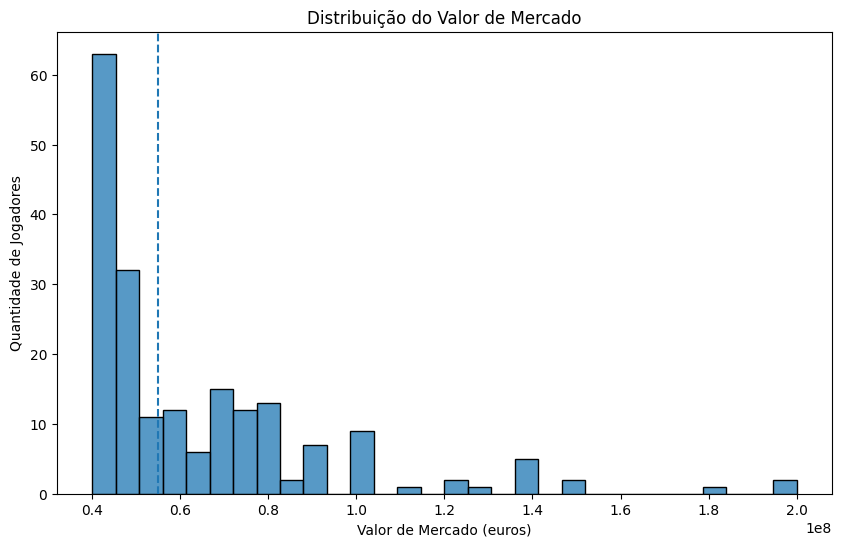

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(
    dataset_final["valor_mercado"].dropna(),
    bins=30
)

plt.axvline(
    dataset_final["valor_mercado"].median(),
    linestyle="--"
)

plt.title("Distribuição do Valor de Mercado")
plt.xlabel("Valor de Mercado (euros)")
plt.ylabel("Quantidade de Jogadores")

plt.show()

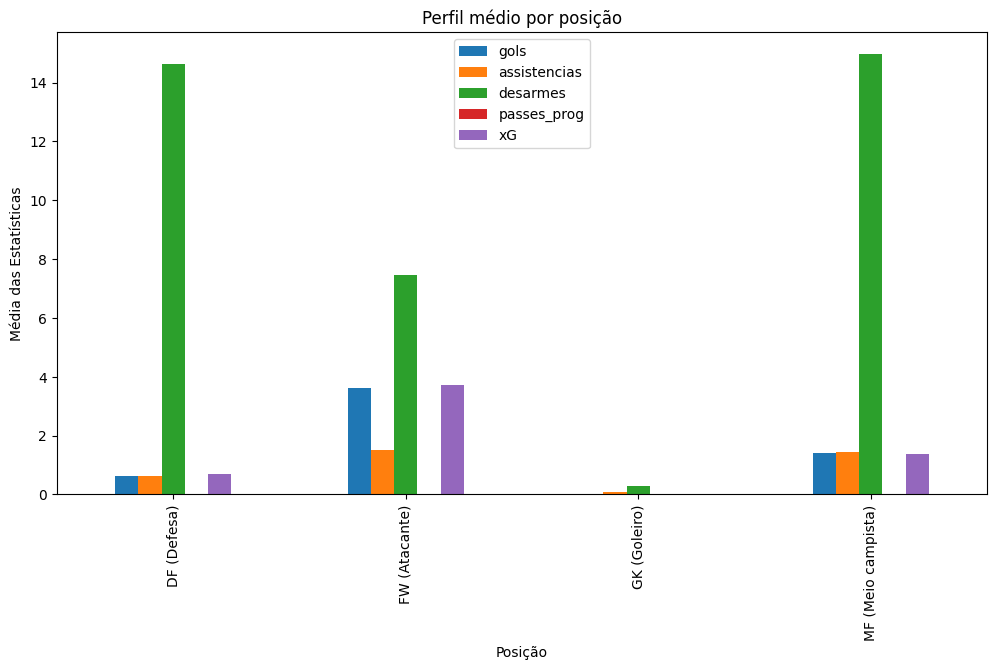

In [37]:
perfil = (
    dataset_final
    .groupby("posicao")
    [
        [
            "gols",
            "assistencias",
            "desarmes",
            "passes_prog",
            "xG"
        ]
    ]
    .mean()
)

perfil.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Perfil médio por posição")
plt.xlabel("Posição")
plt.ylabel("Média das Estatísticas")

plt.show()

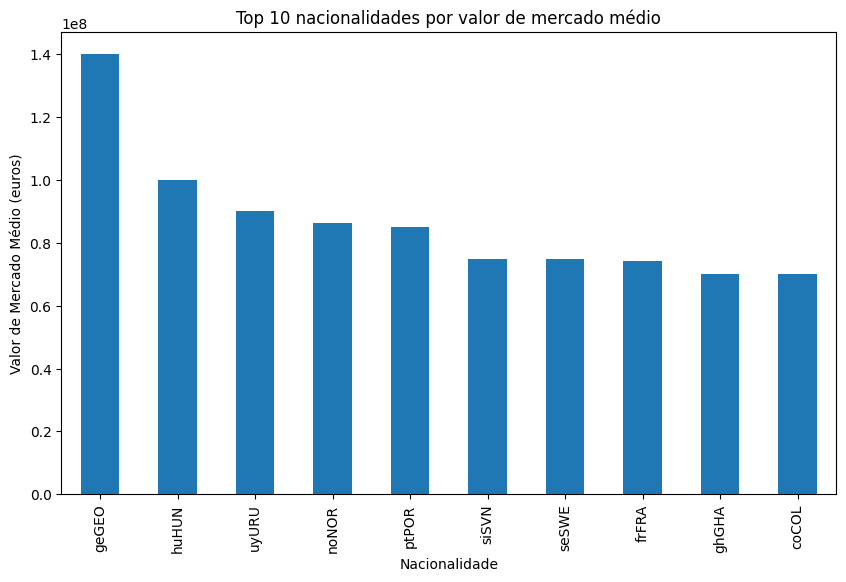

In [48]:
nac = (
    dataset_final
    .groupby("nacionalidade")
    .agg(
        qtd=("nome","count"),
        valor_medio=("valor_mercado","mean")
    )
)

nac = nac[nac["qtd"] >= 5]

top10 = (
    nac
    .sort_values(
        "valor_medio",
        ascending=False
    )
    .head(10)
)

top10["valor_medio"].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Top 10 nacionalidades por valor de mercado médio")
plt.xlabel("Nacionalidade")
plt.ylabel("Valor de Mercado Médio (euros)")

plt.show()

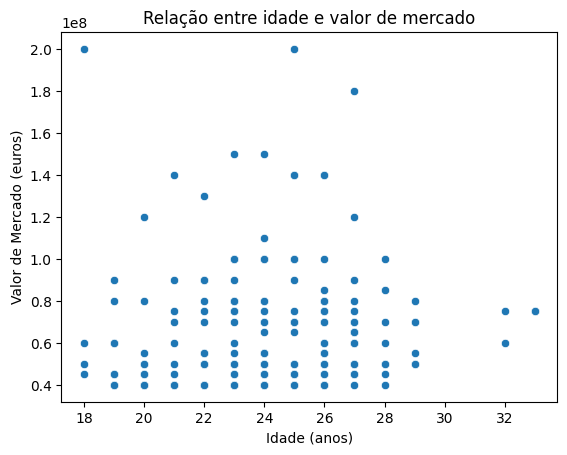

In [45]:
sns.scatterplot(
    data=dataset_final,
    x="idade",
    y="valor_mercado"
)

plt.title("Relação entre idade e valor de mercado")
plt.xlabel("Idade (anos)")
plt.ylabel("Valor de Mercado (euros)")

plt.show()

In [ ]:
#outro gráfico aqui